In [1]:
import torch
import torch.nn as nn
import math

# In this notebook i try to implement a GPT-2 model from scratch

> The knowledge based on the book named **Building a large language model from scratch** from mr **Sebastian Raschka**





## 1. The Basics of Attention: From Input to Output

Let's start with a foundational understanding of the Attention mechanism. The pipeline begins with our raw input text, which is directly processed by a **Tokenizer** and combined with **Positional Embeddings**.

Next, this integrated data is fed into a naive model. In this section, we will:
* Trace the data's journey step-by-step.
* Examine the exact output generated by the Attention layer.
* Observe how the model's parameters are updated.

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [3]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

## Implement a Tokenizer of GPT2 model

In [4]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)


Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [6]:
predicted_token_ids = torch.argmax(logits, dim=-1)
print("Kích thước sau khi lấy argmax:", predicted_token_ids.shape) # [2, 4] tương ứng với [batch_size, seq_len]



Kích thước sau khi lấy argmax: torch.Size([2, 4])


In [7]:
for i, token_sequence in enumerate(predicted_token_ids):
    # Chuyển tensor của PyTorch thành list Python thông thường
    token_list = token_sequence.tolist()

    # Dùng tokenizer để dịch ngược từ list ID thành chuỗi văn bản
    decoded_text = tokenizer.decode(token_list)

    print(f"Dòng {i+1}:")
    print(f"  - Input gốc: '{[txt1, txt2][i]}'")
    print(f"  - Token IDs dự đoán: {token_list}")
    print(f"  - Văn bản model sinh ra: '{decoded_text}'\n")

Dòng 1:
  - Input gốc: 'Every effort moves you'
  - Token IDs dự đoán: [19468, 41068, 49677, 47907]
  - Văn bản model sinh ra: ' granseq UNIVERS Trident'

Dòng 2:
  - Input gốc: 'Every day holds a'
  - Token IDs dự đoán: [44981, 47401, 47117, 22644]
  - Văn bản model sinh ra: ' slurs apologizingRelations directive'



## Making a feed foward layer of GPT-2 model

In [8]:
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available.")

GPU Name: Tesla T4


In [9]:
class relu(nn.Module):
    def __init__(self):
        super(relu,self).__init__()
    def forward(self,x):
        return torch.relu(x)

In [10]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (
            1.0 + torch.tanh(
                math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
            )
        )


In [11]:
cfg = {
    "emb_dim": 768,
    "num_heads": 12,
    "num_layers": 1
}

In [12]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # the input size was 768 and the output quadra it
        GELU(),
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), #convert the output to the original
      )
    def forward(self, x):
      return self.layers(x)

Despite the input is 3 dimension (2,3,768) which can be consider 2 batch each have 3 word and each word have 768 embedding dim. Pytorch can still handle

In [13]:
ffn = FeedForward(cfg)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


In [14]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
    torch.sqrt(torch.tensor(2.0 / torch.pi)) *
    (x + 0.044715 * torch.pow(x, 3))
    ))

## Implement a skip connection architecture which take the last input and plus the current ouput with it. This kind of architecture prevent the vanishing gradient problems

In [15]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]),
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]),
                          GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [16]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)

In [17]:
def print_gradients(model, x):
  output = model(x)
  target = torch.tensor([[0.]])
  loss = nn.MSELoss()
  loss = loss(output, target)
  loss.backward()
  for name, param in model.named_parameters():
    if 'weight' in name:
      print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [18]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


Because we used skip connection
$$ z_L = f(z_l) + x $$
the gradient in the layer $Z_L$ directly influence the gradient of $Z_l$ instead of vanishing  

In [19]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


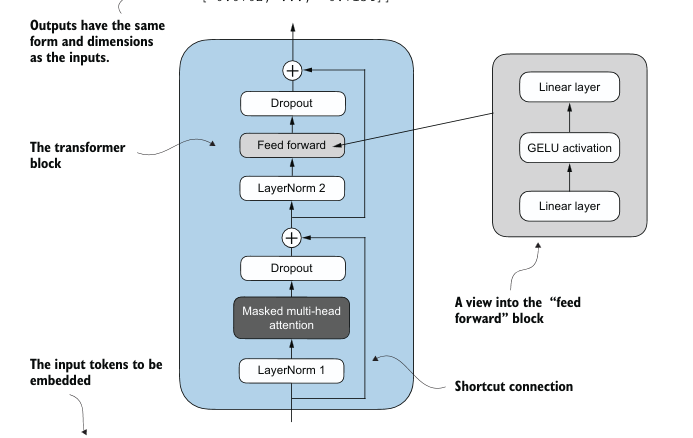

## Masked Self-Attention

Masked self-attention is similar to normal self-attention, but it adds a **causal mask** to prevent each token from attending to future tokens.

In the code, we create a square mask matrix with shape:

$$
(\text{context\_length}, \text{context\_length})
$$

```python
self.register_buffer(
    "mask",
    torch.triu(torch.ones(context_length, context_length), diagonal=1)
)
```

Here, `register_buffer` stores the mask inside the model, but it is **not trainable**.  
It will move automatically with the model when using `.to(device)`, for example from CPU to GPU.

If `context_length = 4`, the causal mask is:

$$
\begin{bmatrix}
0 & 1 & 1 & 1 \\
0 & 0 & 1 & 1 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0
\end{bmatrix}
$$

The value `1` means that position is a future token and should be hidden.

Before applying softmax, these future-token positions are filled with `-inf`:

```python
attn_scores.masked_fill_(
    self.mask.bool()[:n_tokens, :n_tokens],
    -torch.inf
)
```

After softmax, the `-inf` positions become `0`, so the model cannot attend to future tokens.

The original mask shape is:

$$
(\text{context length}, \text{context length})
$$

During the forward pass, it is sliced to match the actual number of tokens:

$$
(n_\text{tokens}, n_\text{tokens})
$$

This matches the attention score shape:

$$
(b, n_\text{tokens}, n_\text{tokens})
$$

In [20]:
class CausalSelfAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout) # New
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, n_tokens, d_in = x.shape # New batch dimension b
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill_(  # New, _ ops are in-place
            self.mask.bool()[:n_tokens, :n_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec


class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalSelfAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )
        self.out_proj = nn.Linear(d_out * num_heads, d_in) # Fixed: project back to d_in

    def forward(self, x):
        context_vec = torch.cat([head(x) for head in self.heads], dim=-1)
        return self.out_proj(context_vec)

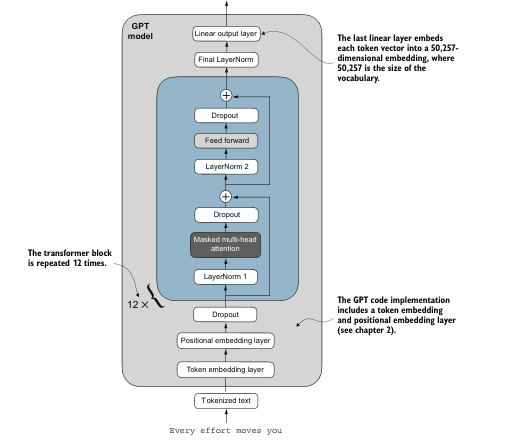

## GPT2 Config

In [21]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [22]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [23]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttentionWrapper(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"] // cfg["n_heads"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [24]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## GPT Model

In [25]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, n_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # (b, n_tokens, d_out)
        # -> (b, n_tokens, num_heads, head_dim)
        keys = keys.view(b, n_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, n_tokens, self.num_heads, self.head_dim)
        values = values.view(b, n_tokens, self.num_heads, self.head_dim)

        # -> (b, num_heads, n_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:n_tokens, :n_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(
            attn_scores / self.head_dim**0.5,
            dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values

        # (b, num_heads, n_tokens, head_dim)
        # -> (b, n_tokens, num_heads, head_dim)
        context_vec = context_vec.transpose(1, 2)

        # -> (b, n_tokens, d_out)
        context_vec = context_vec.contiguous().view(b, n_tokens, self.d_out)

        context_vec = self.out_proj(context_vec)

        return context_vec

In [26]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],          # sửa chỗ này
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x

        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x

        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [27]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [28]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.7955e-01,  2.8515e-01, -7.6131e-01,  ..., -4.8374e-01,
          -4.2503e-01, -1.7187e-01],
         [-6.2581e-01, -3.7480e-01, -9.7020e-01,  ...,  1.9168e-01,
          -1.3234e+00, -2.7643e-01],
         [ 5.1744e-01,  1.3866e-01,  2.4886e-01,  ...,  3.5054e-01,
          -7.7531e-02, -8.0041e-02],
         [-2.5664e-01, -6.9693e-01, -9.9479e-01,  ..., -4.4732e-02,
           6.1772e-02,  1.3467e-01]],

        [[-2.2379e-01,  1.1651e-01, -9.9836e-01,  ..., -1.5730e-01,
          -4.4800e-01, -2.8646e-02],
         [-8.7227e-01, -3.9389e-01, -1.1099e+00,  ...,  3.3035e-01,
          -9.2395e-02, -1.8701e-05],
         [ 4.5988e-01, -1.4274e-01, -1.2227e-01,  ...,  2.7490e-01,
           5.8297e-02, -8.9930e-02],
         [-6.2163e-01, -4.4854e-01, -4.7675e-01,  ..., -3.6519e-01,
           3.4402e-01, -3.8154e-01]]], grad_fn=<UnsafeViewBackward0>)


In [29]:
pip install torchinfo

In [30]:
from torchinfo import summary

summary(
    model,
    input_size=(2, 4),      # batch_size=2, seq_len=4
    dtypes=[torch.long]
)

Layer (type:depth-idx)                   Output Shape              Param #
GPTModel                                 [2, 4, 50257]             --
├─Embedding: 1-1                         [2, 4, 768]               38,597,376
├─Embedding: 1-2                         [4, 768]                  196,608
├─Dropout: 1-3                           [2, 4, 768]               --
├─Sequential: 1-4                        [2, 4, 768]               --
│    └─TransformerBlock: 2-1             [2, 4, 768]               --
│    │    └─LayerNorm: 3-1               [2, 4, 768]               1,536
│    │    └─MultiHeadAttention: 3-2      [2, 4, 768]               2,360,064
│    │    └─Dropout: 3-3                 [2, 4, 768]               --
│    │    └─LayerNorm: 3-4               [2, 4, 768]               1,536
│    │    └─FeedForward: 3-5             [2, 4, 768]               4,722,432
│    │    └─Dropout: 3-6                 [2, 4, 768]               --
│    └─TransformerBlock: 2-2             [2, 4, 768]

In [31]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")


Total number of parameters: 162,419,712


In [32]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 123,822,336


In [33]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [34]:
start_context = "Hello, I am Super"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)


encoded: [15496, 11, 314, 716, 3115]
encoded_tensor.shape: torch.Size([1, 5])


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # disable dropout

encoded_tensor = encoded_tensor.to(device)

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716,  3115, 31721, 46119, 31440, 17828,    39,
          6842]], device='cuda:0')
Output length: 11


In [36]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)



Hello, I am Super Manilabent HK INTH bear


# Install and create dataloader

In [37]:
!gdown --fuzzy https://drive.google.com/file/d/1tXF_6do7lwStNT65aJWVCKTFSPO6wJ5q/view?usp=drive_link

Downloading...
From: https://drive.google.com/uc?id=1tXF_6do7lwStNT65aJWVCKTFSPO6wJ5q
To: /content/the-verdict.txt
100% 20.6k/20.6k [00:00<00:00, 44.6MB/s]


In [38]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
  text_data = file.read()

In [39]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [40]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]



```
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

```



In [41]:
from torch.utils.data import Dataset, DataLoader


In [42]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride): # the stride is the number of new target token?
      self.input_ids = []
      self.target_ids = []
      token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
      for i in range(0, len(token_ids) - max_length, stride):
          input_chunk = token_ids[i:i + max_length]
          target_chunk = token_ids[i + 1: i + max_length + 1]
          self.input_ids.append(torch.tensor(input_chunk))
          self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


In [43]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [44]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [45]:
for batch in train_loader:
    print(batch)
    source,target = batch
    print(source.shape)
    print(target.shape)
    encoded_source = tokenizer.decode(source[0].tolist())
    encoded_target = tokenizer.decode(target[0].tolist())
    print(encoded_source)
    print(encoded_target)
    break

[tensor([[ 1092,   517,   621,   611,   314,  1549,  1239, 12615,   257, 14093,
           526,   198,   198,  1870,   465,  8216,  1297,   502,   287,   257,
          7644,   326,   339,  1239,  1807,   286,  1997,  2073,    13,   198,
           198,    40,  3888,  1497,    11, 43045, 21100,   416,   616, 10059,
          9412,    26,   290,   355,   314,  2900,    11,   616,  4151,  3214,
           319,   257,  1402,  4286,  2029,   262, 24818,   417,    12, 12239,
           438,  1169,   691,  2134,  7163,   262,  8631, 26210,  3425,  9417,
           286,   262,  2119,    13,   198,   198,     1,  5812,    11,   416,
           449,   659,  2474,   314,   531,    13,   198,   198,  1026,   373,
           257, 17548,   286,   257, 50085,   438,   272,  1468, 10032, 50085,
            11,  5055,   287,   262,  6290,   739,   257,  3355,    13,   198,
           198,     1,  3886,   449,   659,   438,    64,   520,  5493,  2474,
           314, 16896,    13,   198,   198,  1544, 

In [46]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [47]:
torch.manual_seed(123)
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [48]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [49]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [50]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [51]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.987583266364204
Validation loss: 10.98110580444336


In [52]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

In [53]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [54]:
# Note:
# Uncomment the following code to calculate the execution time
# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)



In [55]:
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648, Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023, Val loss 6.165
Every effort moves you know                                         

In [56]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [57]:
inputs = inputs.to(device)
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


In [58]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,
    "qkv_bias": True,   # GPT-2 pretrained có bias ở QKV
}

In [59]:
import torch
from transformers import GPT2LMHeadModel


def copy_param(target, source):
    if target.shape != source.shape:
        raise ValueError(
            f"Shape mismatch: target {target.shape}, source {source.shape}"
        )
    with torch.no_grad():
        target.copy_(source)


def load_gpt2_weights_into_custom_model(model, model_name="openai-community/gpt2"):
    hf_model = GPT2LMHeadModel.from_pretrained(model_name)
    hf_model.eval()

    sd = hf_model.state_dict()

    # =========================
    # Embedding
    # =========================
    copy_param(model.tok_emb.weight, sd["transformer.wte.weight"])
    copy_param(model.pos_emb.weight, sd["transformer.wpe.weight"])

    # Weight tying
    copy_param(model.out_head.weight, sd["transformer.wte.weight"])

    # =========================
    # Transformer blocks
    # =========================
    for i, block in enumerate(model.trf_blocks):

        # ----- LayerNorm 1 -----
        copy_param(block.norm1.scale, sd[f"transformer.h.{i}.ln_1.weight"])
        copy_param(block.norm1.shift, sd[f"transformer.h.{i}.ln_1.bias"])

        # ----- Attention QKV -----
        qkv_weight = sd[f"transformer.h.{i}.attn.c_attn.weight"]
        qkv_bias = sd[f"transformer.h.{i}.attn.c_attn.bias"]

        emb_dim = qkv_weight.shape[0]

        # HF GPT-2 c_attn.weight shape: (emb_dim, 3 * emb_dim)
        # Custom Linear weight shape:   (out_features, in_features)

        q_w = qkv_weight[:, :emb_dim].T
        k_w = qkv_weight[:, emb_dim:2 * emb_dim].T
        v_w = qkv_weight[:, 2 * emb_dim:].T

        q_b = qkv_bias[:emb_dim]
        k_b = qkv_bias[emb_dim:2 * emb_dim]
        v_b = qkv_bias[2 * emb_dim:]

        copy_param(block.att.W_query.weight, q_w)
        copy_param(block.att.W_key.weight, k_w)
        copy_param(block.att.W_value.weight, v_w)

        copy_param(block.att.W_query.bias, q_b)
        copy_param(block.att.W_key.bias, k_b)
        copy_param(block.att.W_value.bias, v_b)

        # ----- Attention output projection -----
        copy_param(
            block.att.out_proj.weight,
            sd[f"transformer.h.{i}.attn.c_proj.weight"].T
        )
        copy_param(
            block.att.out_proj.bias,
            sd[f"transformer.h.{i}.attn.c_proj.bias"]
        )

        # ----- LayerNorm 2 -----
        copy_param(block.norm2.scale, sd[f"transformer.h.{i}.ln_2.weight"])
        copy_param(block.norm2.shift, sd[f"transformer.h.{i}.ln_2.bias"])

        # ----- FeedForward / MLP -----
        copy_param(
            block.ff.layers[0].weight,
            sd[f"transformer.h.{i}.mlp.c_fc.weight"].T
        )
        copy_param(
            block.ff.layers[0].bias,
            sd[f"transformer.h.{i}.mlp.c_fc.bias"]
        )

        copy_param(
            block.ff.layers[2].weight,
            sd[f"transformer.h.{i}.mlp.c_proj.weight"].T
        )
        copy_param(
            block.ff.layers[2].bias,
            sd[f"transformer.h.{i}.mlp.c_proj.bias"]
        )

    # =========================
    # Final LayerNorm
    # =========================
    copy_param(model.final_norm.scale, sd["transformer.ln_f.weight"])
    copy_param(model.final_norm.shift, sd["transformer.ln_f.bias"])

    return model

# Loading Pretrained weight

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPTModel(GPT_CONFIG_124M)
model = load_gpt2_weights_into_custom_model(model, "openai-community/gpt2")
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

# Short Answer , the GPT model can still answer because the trained text was organize like "what is AI" and the next word was the answer.

In [61]:
from transformers import GPT2TokenizerFast
import math

tokenizer = GPT2TokenizerFast.from_pretrained("openai-community/gpt2")

text = "What is AI?"
input_ids = tokenizer.encode(text, return_tensors="pt").to(device)

max_new_tokens = 30

for _ in range(max_new_tokens):
    with torch.no_grad():
        logits = model(input_ids)

    logits = logits[:, -1, :]
    next_id = torch.argmax(logits, dim=-1, keepdim=True)

    input_ids = torch.cat([input_ids, next_id], dim=1)

print(tokenizer.decode(input_ids[0]))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

What is AI?

AI is a new field of research that has been gaining traction in recent years. It is a field that has been gaining traction in recent years


In [62]:
while True:
  text = str(input("Ask or esc to exit: "))
  if text == "esc":
    break
  input_ids = tokenizer.encode(text, return_tensors="pt").to(device)
  for _ in range(max_new_tokens):
    with torch.no_grad():
        logits = model(input_ids)

    logits = logits[:, -1, :]
    next_id = torch.argmax(logits, dim=-1, keepdim=True)

    input_ids = torch.cat([input_ids, next_id], dim=1)

  print(tokenizer.decode(input_ids[0]))


Ask or esc to exit: Who are you
Who are you?"

"I'm a man."

"You're a man?"

"I'm a man."

"You're
Ask or esc to exit: what is chatgpt
what is chatgpt?

Chatgpt is a chat client for the Google Chrome browser. It is a simple, fast, and secure chat client.


Ask or esc to exit: esc


In [63]:
pip install huggingface_hub safetensors transformers

In [102]:
from huggingface_hub import  login
login()

In [103]:
import os
import json
import torch
from safetensors.torch import save_file
from transformers import GPT2TokenizerFast

save_dir = "scratch_gpt2_tuned_interview"
os.makedirs(save_dir, exist_ok=True)

# 1. Save model weights
save_file(model.state_dict(), os.path.join(save_dir, "model.safetensors"))

# 2. Save config
with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(GPT_CONFIG_124M, f, indent=2)

# 3. Save tokenizer GPT-2
tokenizer = GPT2TokenizerFast.from_pretrained("openai-community/gpt2")
tokenizer.save_pretrained(save_dir)

print("Saved to:", save_dir)

Saved to: scratch_gpt2_tuned_interview


In [104]:
from huggingface_hub import HfApi, create_repo, upload_folder

repo_id = "dinhxuanhuy/scratch_gpt2_tuned_interview"

create_repo(
    repo_id=repo_id,
    repo_type="model",
    private=False,
    exist_ok=True
)



RepoUrl('https://huggingface.co/dinhxuanhuy/scratch_gpt2_tuned_interview', endpoint='https://huggingface.co', repo_type='model', repo_id='dinhxuanhuy/scratch_gpt2_tuned_interview')

In [105]:
upload_folder(
    folder_path="scratch_gpt2_tuned_interview",
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload custom GPT-2 weights"
)

print("Uploaded:", repo_id)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...terview/model.safetensors:   0%|          |  551kB /  703MB            

Uploaded: dinhxuanhuy/scratch_gpt2_tuned_interview


## Finetuning the model by small dataset

In [68]:
!gdown --fuzzy https://drive.google.com/file/d/1NhfVrwAlMjDeq6I_wipAQ-htpkp8i2J-/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1NhfVrwAlMjDeq6I_wipAQ-htpkp8i2J-
To: /content/huy_interview_dataset.csv
100% 978k/978k [00:00<00:00, 101MB/s]


In [69]:
train_path = "/content/huy_interview_dataset.csv"

In [70]:
import pandas as pd

In [71]:
df = pd.read_csv(train_path)
df.head()

,instruction,answer
0,Can you explain the hybrid 3DGS optimization?,Of course! We implemented a custom culling and...
1,Can you tell me what is your experience with C...,Certainly. I utilize CUDA to accelerate tensor...
2,What are the real-world applications of TameMi...,"Yes, it enables real-time 3D scene reconstruct..."
3,Where do you see yourself in 5 years?,Of course! I aim to become a leading technical...
4,Is your research peer-reviewed?,Of course! We published our findings at the IE...


In [72]:
df.instruction.values

array(['Can you explain the hybrid 3DGS optimization?',
       'Can you tell me what is your experience with CUDA?',
       'What are the real-world applications of TameMini-GS?', ...,
       'What makes you a strong candidate?',
       'Please tell me what is your biggest strength?',
       'Tell me about Gwen?'], dtype=object)

In [84]:
class CustomDataset(Dataset):
    def __init__(self, data_path, tokenizer, max_length=102):
        self.data = pd.read_csv(data_path)
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.src = self.data["instruction"].astype(str).values
        self.tgt = self.data["answer"].astype(str).values

        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question = self.src[idx]
        answer = self.tgt[idx]

        prompt = f"Question: {question}\nAnswer:"
        full_text = f"{prompt} {answer}{self.tokenizer.eos_token}"

        encoded = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = encoded["input_ids"].squeeze(0)
        attention_mask = encoded["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # Tokenize riêng prompt để biết phần nào là câu hỏi
        prompt_encoded = self.tokenizer(
            prompt,
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt"
        )

        prompt_len = prompt_encoded["input_ids"].shape[1]

        # Không tính loss phần Question + Answer:
        labels[:prompt_len] = -100

        # Không tính loss phần padding
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

In [85]:
train_dataset = CustomDataset(
    data_path=train_path,
    tokenizer=tokenizer,
    max_length=102
)

In [86]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [87]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    # Filter out -100 which are used for padding in labels
    valid_token_ids = flat[flat != -100].tolist()
    return tokenizer.decode(valid_token_ids)

In [101]:
for batch in train_loader:
    src,mask,target = batch.values()
    print(src.shape)
    print(mask.shape)
    print(target.shape)
    print(src)
    print(target)
    print(token_ids_to_text(src[0], tokenizer))
    print(token_ids_to_text(mask[0], tokenizer))
    print(token_ids_to_text(target[0], tokenizer))
    break

torch.Size([4, 102])
torch.Size([4, 102])
torch.Size([4, 102])
tensor([[24361,    25, 14026,   502,   546,   257,  6276,  4427,   345,  7452,
            30,   198, 33706,    25, 13403,   319,   616, 15294,    11,   356,
          7452,  3257,  4088,  7095,   618, 20796,   510,   513,    35, 25056,
            13,   314, 12939,   428,   416, 18492, 29605,  1241,    12,  1659,
            12, 49170, 37429,   278,    11, 15882,  1103,    12,  2435,  2854,
           319,  7172, 32516,    13, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256],
        [24361,    25,  1867,   318, 18468,  9792,   290,  6706,  3861,    30,
           198, 33706,    25, 23631,    13, 

# Training

In [96]:
from torch.optim import Adam
from tqdm import tqdm
import torch.nn.functional as F

model.train()
epochs = 3
lr = 5e-5

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)   # [B, T]
        labels = batch["labels"].to(device)         # [B, T]

        logits = model(input_ids)                   # [B, T, vocab_size]

        # GPT dự đoán token tiếp theo
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}")

Epoch 1/3: 100%|██████████| 1275/1275 [04:17<00:00,  4.94it/s, loss=0.126]


Epoch 1 | Train Loss: 0.3755


Epoch 2/3: 100%|██████████| 1275/1275 [04:19<00:00,  4.92it/s, loss=0.15]


Epoch 2 | Train Loss: 0.1815


Epoch 3/3: 100%|██████████| 1275/1275 [04:19<00:00,  4.91it/s, loss=0.213]

Epoch 3 | Train Loss: 0.1751


In [97]:
while True:
  text = str(input("Ask or esc to exit: "))
  if text == "esc":
    break
  input_ids = tokenizer.encode(text, return_tensors="pt").to(device)
  for _ in range(max_new_tokens):
    with torch.no_grad():
        logits = model(input_ids)

    logits = logits[:, -1, :]
    next_id = torch.argmax(logits, dim=-1, keepdim=True)

    input_ids = torch.cat([input_ids, next_id], dim=1)

  print(tokenizer.decode(input_ids[0]))


Ask or esc to exit: Can you explain the hybrid 3DGS optimization?
Can you explain the hybrid 3DGS optimization? We integrated advanced culling and densification mechanisms to remove redundant Gaussian primitives and maintain high scene quality. I hope this answers your question.<|endoftext|>
Ask or esc to exit: Can you tell me what is your experience with CUDA?
Can you tell me what is your experience with CUDA? I have experience working with CUDA for GPU acceleration, particularly in optimizing rendering pipelines in TameMini-GS. I am happy to elaborate further.


KeyboardInterrupt: Interrupted by user

In [100]:
while True:
    text = str(input("Ask or esc to exit: "))

    if text == "esc":
        break

    prompt = f"Question: {text}\nAnswer:"
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(input_ids)

        logits = logits[:, -1, :]
        next_id = torch.argmax(logits, dim=-1, keepdim=True)

        input_ids = torch.cat([input_ids, next_id], dim=1)

        # dừng nếu model sinh eos
        if next_id.item() == tokenizer.eos_token_id:
            break

        # tránh vượt quá context_length của model
        if input_ids.shape[1] >= GPT_CONFIG_124M["context_length"]:
            break

    output_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)

    # chỉ lấy phần sau Answer:
    answer = output_text.split("Answer:", 1)[-1].strip()

    print(answer)

Ask or esc to exit: How did you handle a major bottleneck in a project?
Yes, we faced extreme memory limits when scaling up 3D reconstruction. I resolved this by designing adaptive level-of-detail culling, enabling real
Ask or esc to exit: Describe your leadership style?
Yes, I am a collaborative leader. I delegate tasks based on members' strengths, hold regular sync-ups, and ensure open communication to resolve bott
Ask or esc to exit: esc
